# 01 — PyTorch baselines (FP32 / FP16)

Runs:
- FP32 (CUDA)
- FP16 (CUDA)

Optionally without reduced bit depth.

In [1]:
from pathlib import Path
import sys, os

# ---- Path setup (adjust if your repo layout differs) ----
PROJECT_ROOT = Path("..").resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [6]:
# Purpose: Establish PyTorch FP32 baseline (and optional FP16 baseline) on ImageNet val.
import os
import json
from pathlib import Path
import pandas as pd

# project imports
from config import ExperimentConfig, with_overrides
from runner import run_experiment
from utils import load_runs, flatten_runs
from plots import (
    plot_metric_vs_input_bits,
    plot_tradeoff_with_pareto,
    plot_tradeoff_scatter,
)

pd.set_option("display.max_columns", 200)

In [9]:
# Baselines (PyTorch backend only)
base = ExperimentConfig(
    backend="pytorch",
    device="cuda",              # set "cpu" if you want CPU baseline
    batch_size=256,
    model_precision="fp32",
    input_quant_bits=0,         # 0 = no input quantization
    seed=42,
)

cfgs = [base, with_overrides(base, model_precision="fp16")]

In [10]:
records = []

for cfg in cfgs:
    payload, tracker = run_experiment(cfg, split="val", save_results_flag=True)
    records.append(payload)

# quick peek
for r in records:
    print(r["run_id"], r["status"], r["results"].get("top1_acc"))

Evaluating on 195 batches...
  Batch [10/195] Top-1: 78.52% | Top-5: 93.16% | Infer: 177.05 ms/batch
  Batch [20/195] Top-1: 76.66% | Top-5: 92.68% | Infer: 136.84 ms/batch
  Batch [30/195] Top-1: 77.93% | Top-5: 92.85% | Infer: 123.09 ms/batch
  Batch [40/195] Top-1: 76.23% | Top-5: 92.95% | Infer: 116.22 ms/batch
  Batch [50/195] Top-1: 75.80% | Top-5: 93.20% | Infer: 112.18 ms/batch
  Batch [60/195] Top-1: 75.70% | Top-5: 93.38% | Infer: 109.41 ms/batch
  Batch [70/195] Top-1: 76.21% | Top-5: 93.53% | Infer: 107.60 ms/batch
  Batch [80/195] Top-1: 76.14% | Top-5: 93.37% | Infer: 106.14 ms/batch
  Batch [90/195] Top-1: 74.97% | Top-5: 92.59% | Infer: 104.97 ms/batch
  Batch [100/195] Top-1: 73.58% | Top-5: 91.71% | Infer: 104.12 ms/batch
  Batch [110/195] Top-1: 72.93% | Top-5: 91.26% | Infer: 103.34 ms/batch
  Batch [120/195] Top-1: 72.68% | Top-5: 90.92% | Infer: 102.80 ms/batch
  Batch [130/195] Top-1: 71.64% | Top-5: 90.37% | Infer: 102.24 ms/batch
  Batch [140/195] Top-1: 71.31%

In [11]:
# Always load from disk (the source of truth)
runs = load_runs("./runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

# Filter to just this notebook’s scope (pytorch + no input quant)
df_baselines = df[
    (df["cfg.backend"] == "pytorch")
    & (df["cfg.input_quant_bits"] == 0)
    & (df["cfg.model_precision"].isin(["fp32", "fp16"]))
].copy()

df_baselines[[
    "run_id",
    "cfg.backend",
    "cfg.device",
    "cfg.batch_size",
    "cfg.model_precision",
    "cfg.input_quant_bits",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.throughput_infer_sps",
    "res.total_samples",
]].sort_values(["cfg.model_precision", "cfg.device"])

,run_id,cfg.backend,cfg.device,cfg.batch_size,cfg.model_precision,cfg.input_quant_bits,res.top1_acc,res.top5_acc,res.infer_ms_avg,res.throughput_infer_sps,res.total_samples
0,resnet18_pytorch_fp16_in0b_cuda_bs256,pytorch,cuda,256,fp16,0,69.805689,89.114583,55.228390,4635.297214,49920
2,resnet18_pytorch_fp32_in0b_cuda_bs256,pytorch,cuda,256,fp32,0,69.799679,89.100561,100.024455,2559.374103,49920


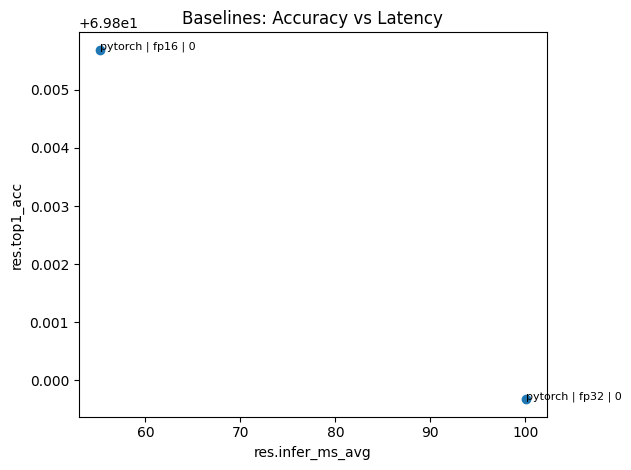

In [ ]:
plot_tradeoff_scatter(
    rows_baselines,
    x_key="res.infer_ms_avg",
    y_key="res.top1_acc",
    title="Baselines: Accuracy vs Latency",
    annotate=True,
)

In [14]:
obs = []

if not df_baselines.empty:
    # pick fp32 as baseline row (first match)
    fp32 = df_baselines[df_baselines["cfg.model_precision"] == "fp32"].head(1)
    if len(fp32) == 1:
        top1 = float(fp32["res.top1_acc"].iloc[0])
        ms = float(fp32["res.infer_ms_avg"].iloc[0])
        sps = float(fp32["res.throughput_infer_sps"].iloc[0])
        obs.append(f"FP32 baseline (PyTorch, in_bits=0): Top-1={top1:.2f}%, infer={ms:.2f} ms/batch, throughput={sps:.1f} samples/s.")

    fp16 = df_baselines[df_baselines["cfg.model_precision"] == "fp16"].head(1)
    if len(fp16) == 1 and len(fp32) == 1:
        top1_16 = float(fp16["res.top1_acc"].iloc[0])
        ms_16 = float(fp16["res.infer_ms_avg"].iloc[0])
        ms_32 = float(fp32["res.infer_ms_avg"].iloc[0])
        obs.append(f"FP16 vs FP32: ΔTop-1={top1_16 - top1:.2f}pp, speedup={ms_32/ms_16:.2f}× (lower is faster).")

print("\n".join(f"- {x}" for x in obs) if obs else "No observations yet.")

- FP32 baseline (PyTorch, in_bits=0): Top-1=69.80%, infer=100.02 ms/batch, throughput=2559.4 samples/s.
- FP16 vs FP32: ΔTop-1=0.01pp, speedup=1.81× (lower is faster).
